# Airbnb market EDA, ETL and Visualization
#### https://www.kaggle.com/datasets/jasonairroi/airbnb-market-data-europe

# Analyse:
- What metrics are more relevant
- What amenities are more relevant
- Estimate how well an announcement will go
- Estimate price based on announcement
- Estimate which announcements are better for each season
- Analyse which cities are more visited

In [ ]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Setting up libraries configurations

# Pandas:
pd.set_option('display.max_rows', 61)
pd.set_option('display.max_row', 61)
pd.set_option('display.date_yearfirst', True)
pd.option_context('display.max_rows', None)

# Matplotlib defaults


# Listings:

In [ ]:
# Constants
LISTING_DATASET = "../data/listings.parquet"
EXACT_COLUMNS_LISTINGS = ['listing_id', 'listing_type', 'room_type', 'cover_photo_url', 'photos_count', 'host_id', 
                'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'registration', 
                'amenities', 'instant_book', 'professional_management', 'min_nights', 'cancellation_policy', 
                'currency', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 
                'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 
                'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_occupancy', 
                'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
                'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 
                'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 
                'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 
                'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_blocked_days', 
                'l90d_available_days', 'l90d_total_days', 'country', 'state', 'city'
]
TARGET_COLS = ['ttm_revenue']

In [77]:
# Reading data
df_pqt = pd.read_parquet(LISTING_DATASET)
# df_dsv = pd.read_csv(LISTING_DATASET_CSV, sep=',')
df_pqt.head()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_revpar_native,l90d_adjusted_revpar,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6,...,0.0,0.0,0.0,0,90,90,90,Turkey,Muğla,Bodrum
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum
3,853827,Entire villa,entire_home,https://a0.muscache.com/im/pictures/26626113/a...,70,605fc7d80e02,false,37.0434,27.2517,16,...,536.3,0.0,0.0,2,0,88,90,Turkey,Muğla,Bodrum
4,967193,Entire villa,entire_home,https://a0.muscache.com/im/pictures/68107669/2...,37,3b963e8cd040,false,37.0429,27.3898,4,...,0.0,0.0,0.0,0,0,90,90,Turkey,Muğla,Bodrum


In [78]:
# Analysing columns
print(list(df_pqt.columns) == EXACT_COLUMNS_LISTINGS)

True


In [79]:
# Checking Non-Nulls, Nulls and Columns types
non_null_count_listings = df_pqt.notnull().sum().values
nulls = df_pqt.isna().sum()
types = df_pqt.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)


                             Non-Null Count  Null Count Dtypes
listing_id                            95898           0    str
listing_type                          95329         569    str
room_type                             95329         569    str
cover_photo_url                       95102         796    str
photos_count                          95102         796    str
host_id                               95329         569    str
superhost                             95322         576    str
latitude                              95327         571    str
longitude                             95273         625    str
guests                                84865       11033    str
bedrooms                              78576       17322    str
beds                                  94336        1562    str
baths                                 94994         904    str
registration                          95064         834    str
amenities                             94960         938

In [81]:
# Defining correct columns dtypes

str_cols = [
    'listing_type', 'room_type', 'cover_photo_url', 'host_id', 'amenities', 'cancellation_policy', 
    'currency', 'country', 'state', 'city'
]

bool_cols = [
    'superhost', 'registration', 'instant_book', 'professional_management'
]

float_cols = [
    'latitude', 'longitude', 'beds', 'baths', 'rating_overall', 'rating_accuracy', 'rating_checkin', 
    'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_avg_rate', 
    'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_revpar', 'ttm_revpar_native',
    'ttm_adjusted_revpar', 'ttm_adjusted_revpar_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 
    'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 
    'l90d_adjusted_revpar_native'
]

int_cols = [
    'listing_id', 'photos_count', 'guests', 'bedrooms', 'min_nights', 
    'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'ttm_revenue', 'ttm_revenue_native',
    'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days',
    'l90d_revenue', 'l90d_revenue_native', 'l90d_reserved_days', 'l90d_blocked_days',
    'l90d_available_days', 'l90d_total_days'
]

print(len(EXACT_COLUMNS_LISTINGS) == (len(str_cols) + len(bool_cols) + len(float_cols) + len(int_cols)))

True


# ETL

### Removing columns:

In [82]:
# Remove columns:
#   - latitude
#   - longitude
#   - l90d_*
#   - ttm_*_native

str_cols_to_remove = ['currency']
float_cols_to_remove = ['latitude', 'longitude',  'ttm_avg_rate_native', 
                'ttm_revpar_native', 'ttm_adjusted_revpar_native',  
                'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_occupancy', 'l90d_adjusted_occupancy', 
                'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar', 'l90d_adjusted_revpar_native',               
]
int_cols_to_remove = ['ttm_revenue_native', 'ttm_total_days', 'l90d_revenue', 'l90d_revenue_native', 
                    'l90d_reserved_days', 'l90d_blocked_days', 'l90d_available_days', 'l90d_total_days'
]
cols_to_remove = str_cols_to_remove + float_cols_to_remove + int_cols_to_remove

df_fixing = df_pqt.drop(cols_to_remove, axis=1)

print(len(EXACT_COLUMNS_LISTINGS) - len(cols_to_remove) == len(df_fixing.columns))
print(len(df_fixing))

True
95898


### Convert (and remove):

In [83]:
# Int: 
#    - "float" --> round() int
#    - else --> NaN
# Float: 
#    - "float" --> float
#    - else --> NaN

# Defining new numeric columns
new_float_cols = [col for col in float_cols if col not in float_cols_to_remove]
new_int_cols = [col for col in int_cols if col not in int_cols_to_remove]
new_numeric_cols = new_float_cols + new_int_cols

# Changing str to numeric
df_fixing[new_numeric_cols] = df_fixing[new_numeric_cols].apply(pd.to_numeric, errors="coerce")

# Changing inf to nan
df_fixing[new_numeric_cols] = df_fixing[new_numeric_cols].replace([np.inf, -np.inf], np.nan)

def safe_convert(series):
    numeric = pd.to_numeric(series, errors="coerce")
    is_whole = numeric == numeric.round()
    return numeric.where(is_whole).astype("Int64")

# Convert float to int where needed
df_fixing[new_int_cols] = df_fixing[new_int_cols].apply(safe_convert)

print(len(df_fixing))

95898


In [84]:
# Booleans: 
#    - NA --> NA
#    - false --> False
#    - true --> True
#    - else --> drop row

for col in bool_cols:
    s = df_fixing[col].astype(str).str.strip().str.lower()
    df_fixing[col] = s.map({"true": True, "false": False}).astype("boolean")

print(df_fixing[bool_cols].dtypes, "\n")   # should show boolean
print(df_fixing[bool_cols].isna().sum())   # count of NAs per column

print(len(df_fixing))

superhost                  boolean
registration               boolean
instant_book               boolean
professional_management    boolean
dtype: object 

superhost                   1052
registration                1317
instant_book               76192
professional_management    11293
dtype: int64
95898


### Drop inconsistent rows (define limits and remove outliers):

In [85]:
df_fixing = df_fixing[
    # Keeping rows without inconcistencies between bedrooms, beds, guests and baths
    (df_fixing["bedrooms"] <= df_fixing["beds"]) &
    (df_fixing["bedrooms"] <= df_fixing["guests"]) & 
    (df_fixing["beds"] <= df_fixing["guests"]) &
    (df_fixing["baths"] <= df_fixing["guests"]) & 
    (df_fixing["baths"] <= df_fixing["beds"]) & 
    (df_fixing["baths"] <= df_fixing["bedrooms"] * 2) &

    # Keeping rows with rating between 0 and 5 stars
    ((df_fixing["rating_overall"] >= 0) & (df_fixing["rating_overall"] <= 5)) &
    ((df_fixing["rating_accuracy"] >= 0) & (df_fixing["rating_accuracy"] <= 5)) &
    ((df_fixing["rating_checkin"] >= 0) & (df_fixing["rating_checkin"] <= 5)) &
    ((df_fixing["rating_cleanliness"] >= 0) & (df_fixing["rating_cleanliness"] <= 5)) &
    ((df_fixing["rating_communication"] >= 0) & (df_fixing["rating_communication"] <= 5)) &
    ((df_fixing["rating_location"] >= 0) & (df_fixing["rating_location"] <= 5)) &
    ((df_fixing["rating_value"] >= 0) & (df_fixing["rating_value"] <= 5)) &
    
    # Kepping rows with more than 0 days/nights 
    (df_fixing["ttm_reserved_days"] >= 0) &
    (df_fixing["ttm_blocked_days"] >= 0) &
    (df_fixing["ttm_available_days"] >= 0) &
    (df_fixing["min_nights"] >= 0) &

    # Keeping rows with reasonable amount of photos_count
    (df_fixing["photos_count"] <= 100)
]

print(len(df_fixing))

68702


### Adding column

In [86]:
# Add column:
# - amenities_count

all_amenities = set(str())

amenities_counts = list()

print(df_fixing["amenities"].isna().sum())
df_fixing = df_fixing.dropna(subset="amenities")

for i in range(len(df_fixing)):
    amenities = df_fixing["amenities"].iloc[i].split(",")

    all_amenities.update(amenities)
    amenities_counts.append(len(amenities))

df_fixing.insert(13, "amenities_count", amenities_counts)

new_numeric_cols.insert(4, "amenities_count")

3


In [ ]:
# Verifying data frame
non_null_count_listings = df_fixing.notnull().sum().values
nulls = df_fixing.isna().sum()
types = df_fixing.dtypes.values

info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)

                         Non-Null Count  Null Count   Dtypes
listing_id                        68683          16    Int64
listing_type                      68699           0      str
room_type                         68699           0      str
cover_photo_url                   68699           0      str
photos_count                      68699           0    Int64
host_id                           68699           0      str
superhost                         68699           0  boolean
guests                            68699           0    Int64
bedrooms                          68699           0    Int64
beds                              68699           0  float64
baths                             68699           0  float64
registration                      68474         225  boolean
amenities                         68699           0      str
amenities_count                   68699           0    int64
instant_book                      14283       54416  boolean
professional_management 

### Creating new clean .parquet file

In [88]:
# Creating new clean .parquet file
df_fixing.to_parquet(path="../data/clean_listings.parquet")

df_clean = pd.read_parquet("../data/clean_listings.parquet")

# Visualize

#### Tables:
1. Basic Overview
2. Distributions of key numeric columns
3. Revenue & performance analysis
4. Ratings analysis
5. Geographic analysis
6. Correlation heatmap (numeric columns)
7. Amenities analysis
8. Occupancy calendar breakdown

#### 1. Basic Overview

In [99]:
info_df = pd.DataFrame({
    'Non-Null Count': non_null_count_listings,
    'Null Count': nulls,
    'Dtypes': types
})
print(info_df)

                         Non-Null Count  Null Count   Dtypes
listing_id                        68683          16    Int64
listing_type                      68699           0      str
room_type                         68699           0      str
cover_photo_url                   68699           0      str
photos_count                      68699           0    Int64
host_id                           68699           0      str
superhost                         68699           0  boolean
guests                            68699           0    Int64
bedrooms                          68699           0    Int64
beds                              68699           0  float64
baths                             68699           0  float64
registration                      68474         225  boolean
amenities                         68699           0      str
amenities_count                   68699           0    int64
instant_book                      14283       54416  boolean
professional_management 

#### 2. Distributions of key numeric columns

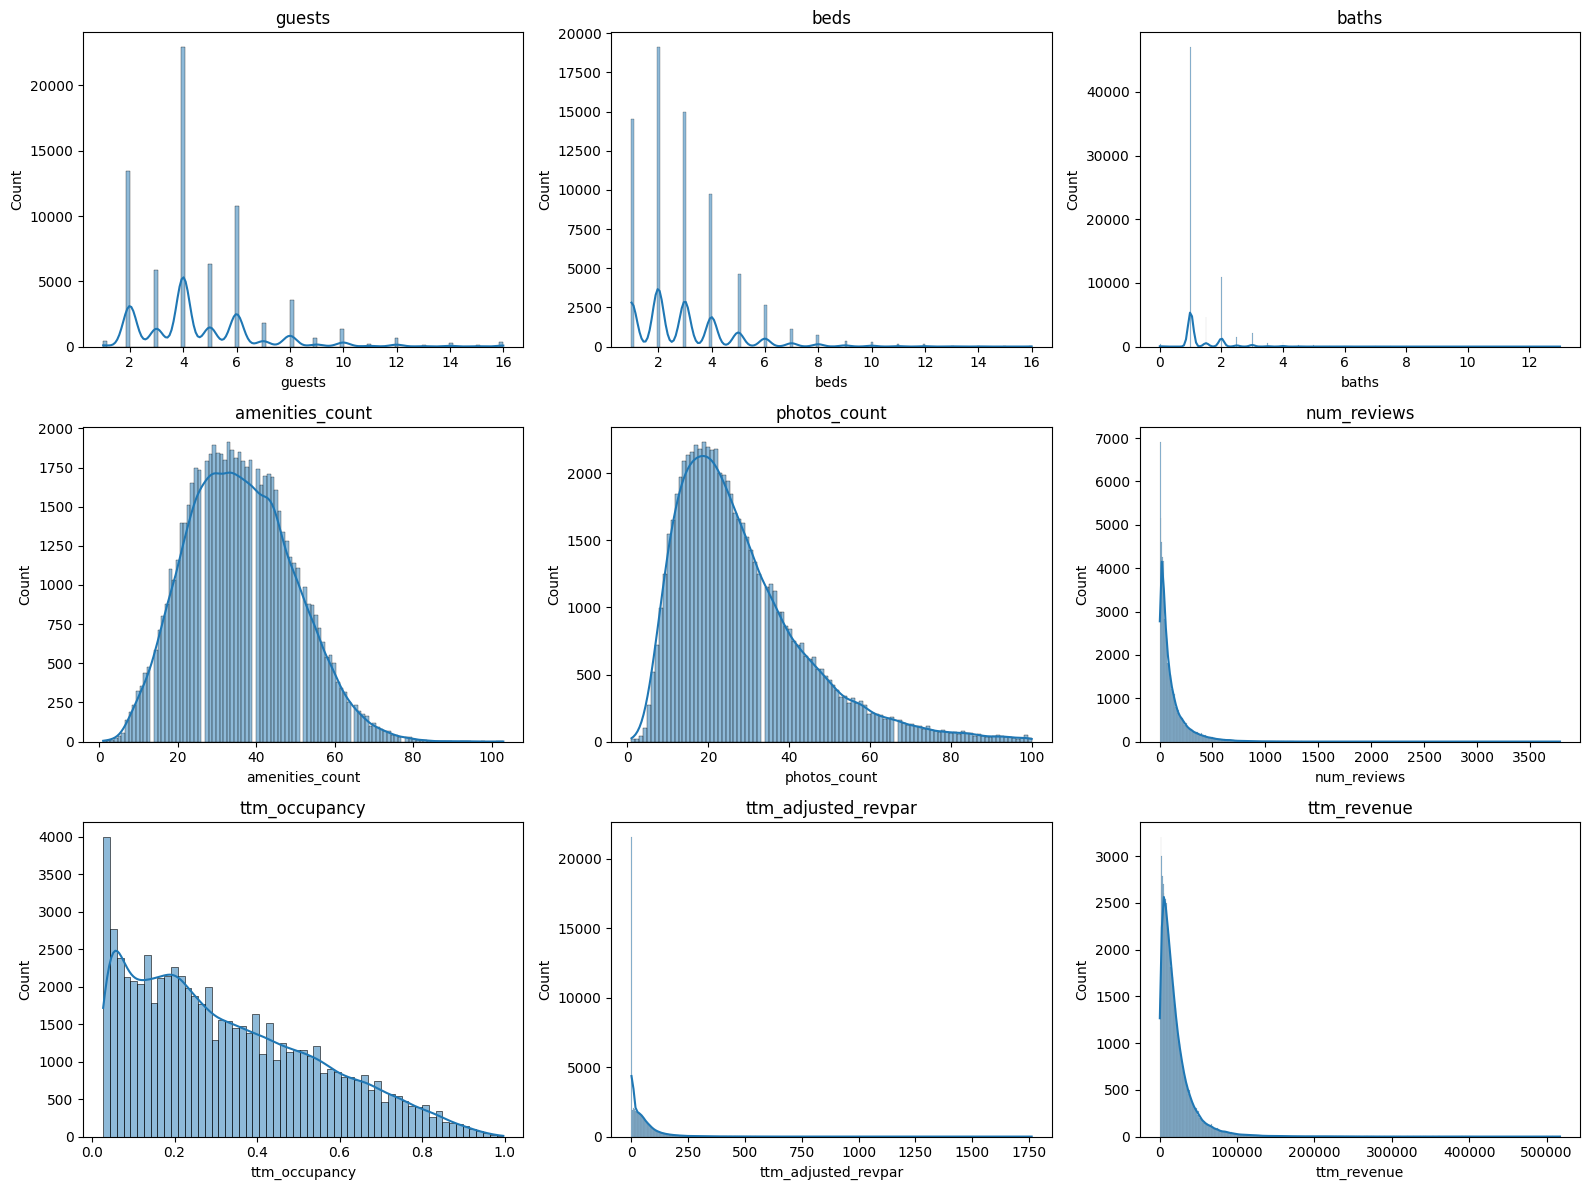

In [ ]:
key_numeric_cols = ['guests', 'beds', 'baths', 'amenities_count', 'photos_count', 'num_reviews', 
                    'ttm_occupancy', 'ttm_adjusted_revpar', 'ttm_revenue'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, col in zip(axes.flatten(), key_numeric_cols):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()


#### 3. Revenue & performance analysis

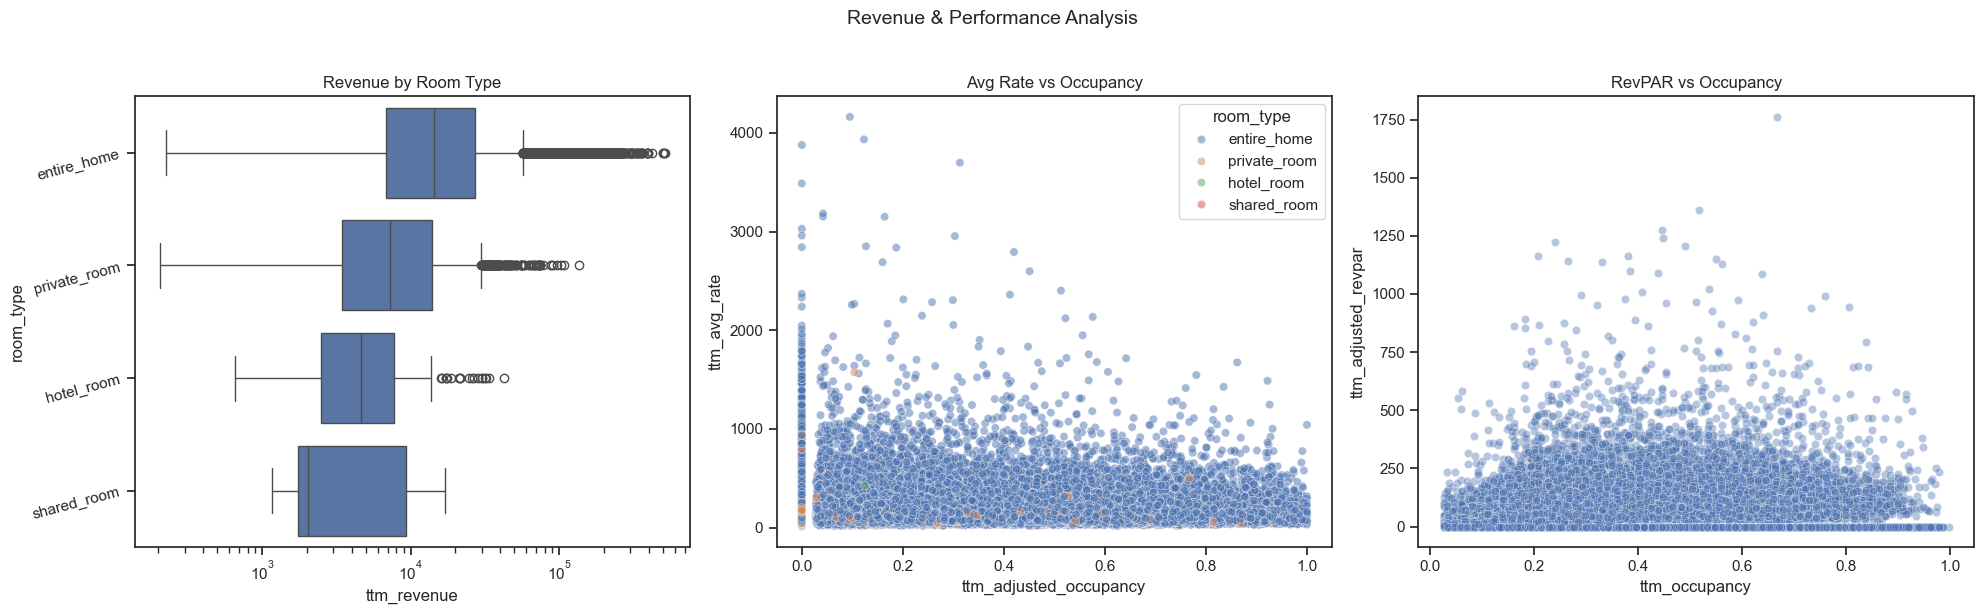

In [252]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Revenue by room type
sns.boxplot(data=df_clean, x="ttm_revenue", y="room_type", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Revenue by Room Type")
axes[0].tick_params(axis="y", rotation=15)

# Occupancy vs avg rate
sns.scatterplot(data=df_clean, x="ttm_adjusted_occupancy", y="ttm_avg_rate", 
                hue="room_type", alpha=0.5, ax=axes[1])
axes[1].set_title("Avg Rate vs Occupancy")

# RevPAR vs occupancy
sns.scatterplot(data=df_clean, x="ttm_occupancy", y="ttm_adjusted_revpar",
                alpha=0.4, ax=axes[2])
axes[2].set_title("RevPAR vs Occupancy")

plt.suptitle("Revenue & Performance Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### 4. Ratings analysis

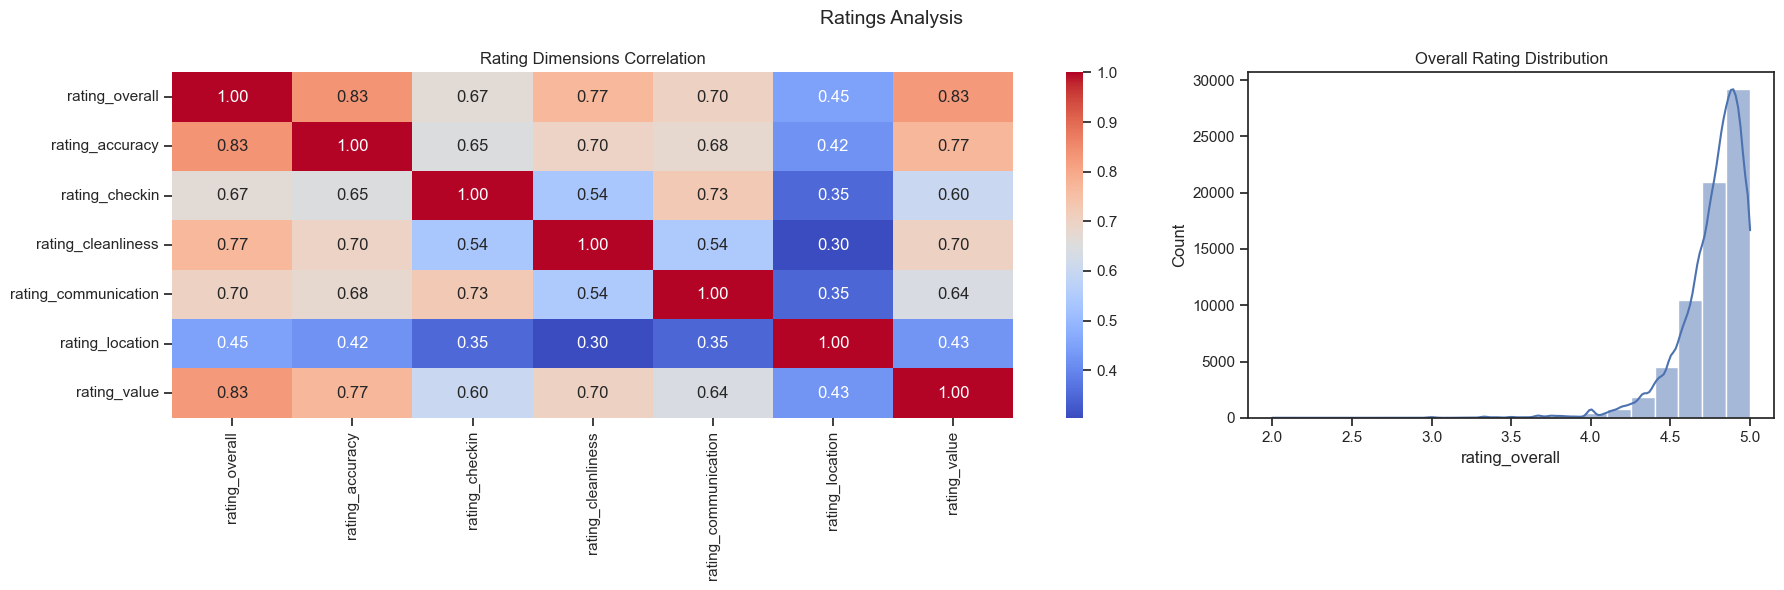

In [253]:
rating_cols = ["rating_overall", "rating_accuracy", "rating_checkin", "rating_cleanliness", 
               "rating_communication", "rating_location", "rating_value"
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [2, 1]})

# Correlation heatmap (wider)
sns.heatmap(df_clean[rating_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[0])
axes[0].set_title("Rating Dimensions Correlation")

# Distribution of overall rating (narrower)
sns.histplot(df_clean["rating_overall"].dropna(), bins=20, kde=True, ax=axes[1])
axes[1].set_title("Overall Rating Distribution")

plt.suptitle("Ratings Analysis", fontsize=14)
plt.tight_layout()
plt.show()

#### 5. Geographic analysis

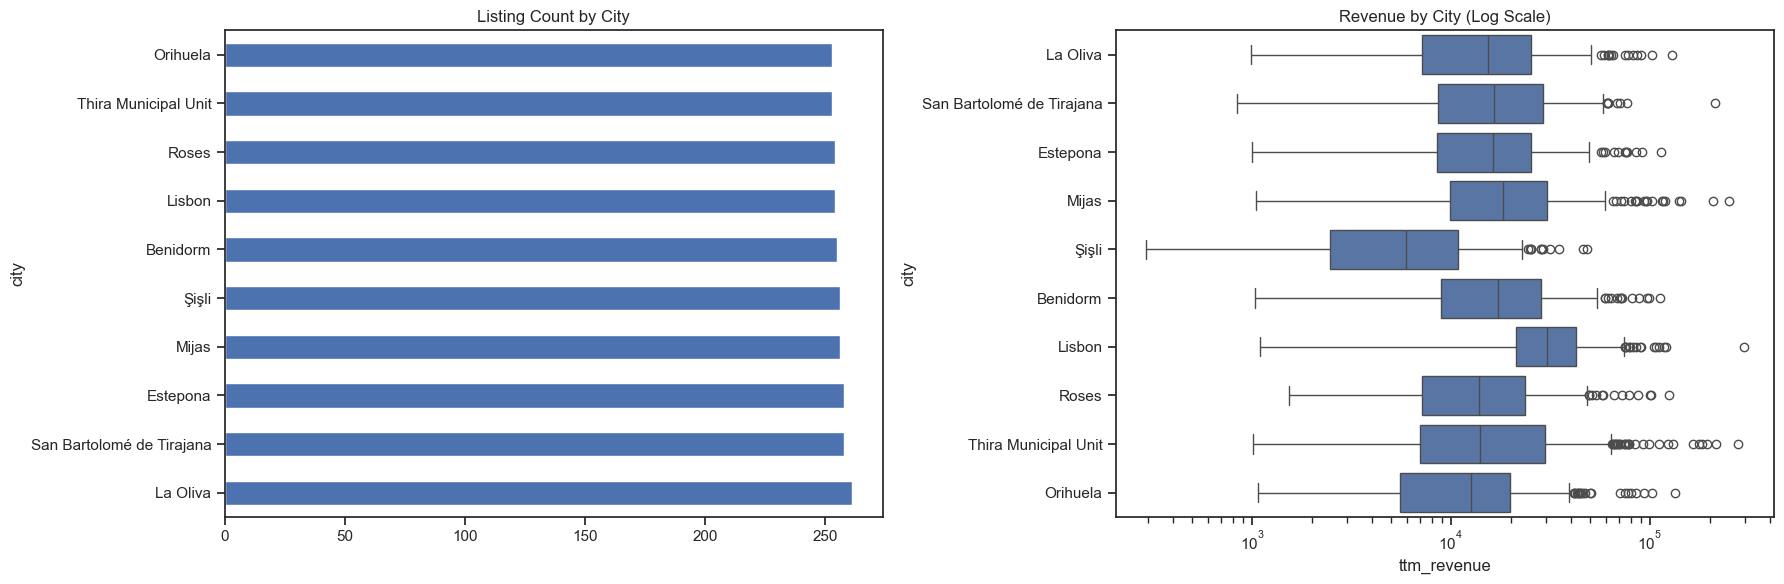

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cities = df_clean["city"].value_counts().head(10).index

# Listing count by city
df_clean["city"].value_counts().head(10).plot(kind="barh", ax=axes[0])
axes[0].set_title("Listing Count by City")

# Revenue by city
sns.boxplot(data=df_clean[df_clean["city"].isin(top_cities)], 
            x="ttm_revenue", y="city", 
            order=top_cities, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Revenue by City (Log Scale)")

plt.tight_layout()
plt.show()

#### 6. Correlation heatmap (numeric columns)


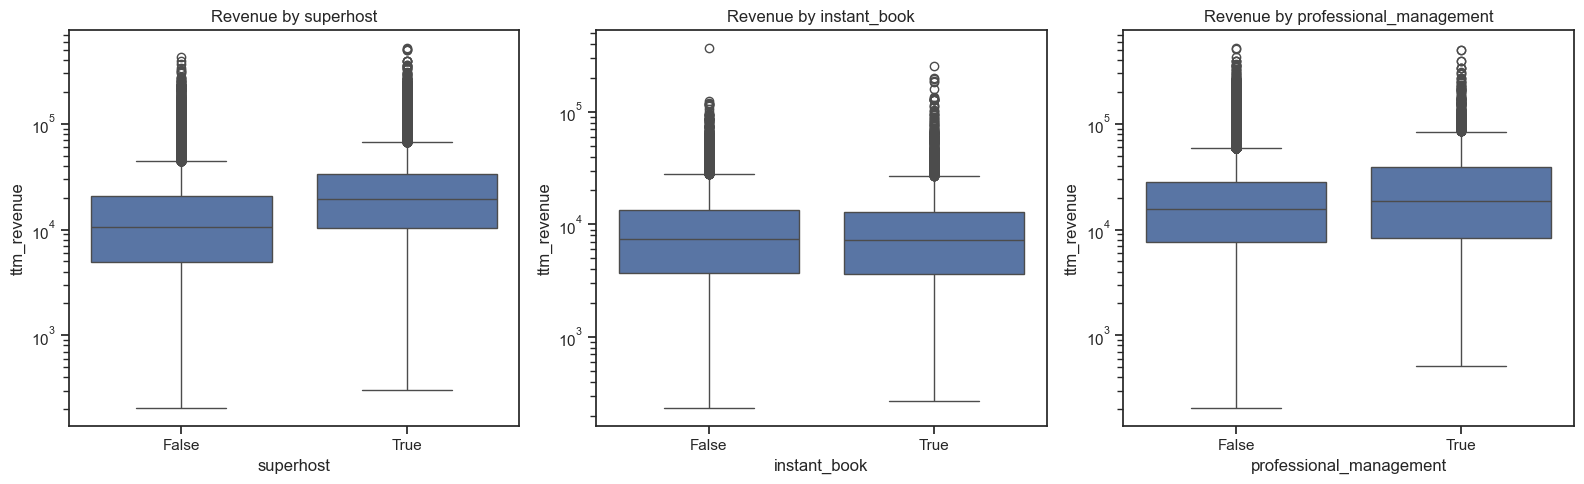

In [243]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["superhost", "instant_book", "professional_management"]):
    data = df_clean.copy()
    data[col] = data[col].astype(str)
    sns.boxplot(data=data, x=col, y="ttm_revenue", ax=ax)
    ax.set_yscale("log")  # log on y (revenue), not x (boolean category)
    ax.set_title(f"Revenue by {col}")
plt.tight_layout()

#### 7. Amenities analysis

Text(0.5, 1.0, 'Top 20 Amenities')

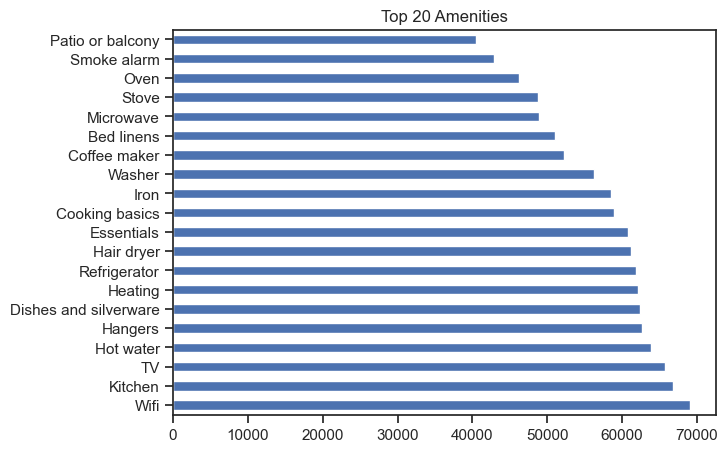

In [247]:
# Most common amenities (assuming comma-separated string)
from collections import Counter

all_amenities = df_clean["amenities"].dropna().str.split(",").explode().str.strip()
top_amenities = pd.Series(Counter(all_amenities)).sort_values(ascending=False).head(20)
top_amenities.plot(kind="barh", figsize=(7, 5))
plt.title("Top 20 Amenities")

#### 8. Occupancy calendar breakdown

<Axes: title={'center': 'Avg Day Distribution per Listing'}>

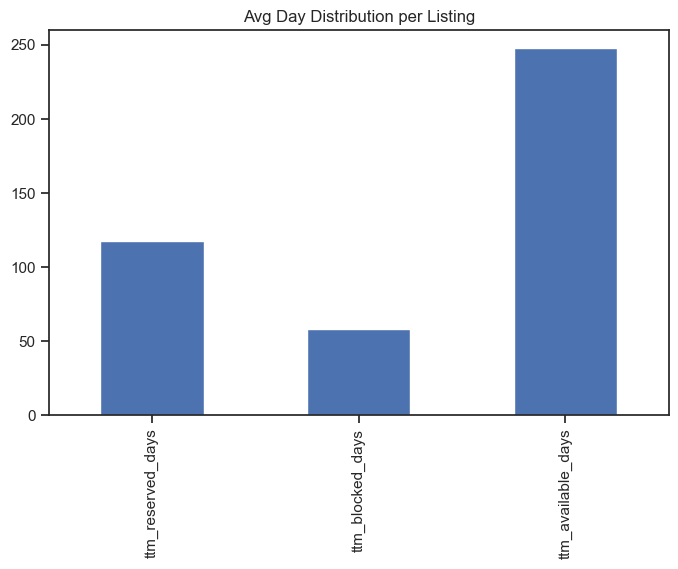

In [248]:
# How days are distributed: reserved vs blocked vs available
day_cols = ["ttm_reserved_days", "ttm_blocked_days", "ttm_available_days"]
df_clean[day_cols].mean().plot(kind="bar", figsize=(8, 5), title="Avg Day Distribution per Listing")